###WATER QUALITY DETECTION ANALYSIS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import f1_score, precision_score, recall_score

In [ ]:
# Load the data
df = pd.read_csv('/content/drive/MyDrive/ALX Task/water_potability.csv')

In [ ]:
# See the first 5 rows
print("FIRST 5 ROWS")
print(df.head())

# See the shape (rows, columns)
print("\n SHAPE")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# See column names and data types
print("\n COLUMN INFO")
print(df.info())

# See basic statistics
print("\n STATISTICS")
print(df.describe())

FIRST 5 ROWS
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

 SHAPE
Rows: 3276, Columns: 10

 COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 col

In [ ]:
# Count missing values in each column
print("MISSING VALUES")
print(df.isnull().sum())

# Show percentage of missing values
print("\n MISSING VALUES PERCENTAGE")
print((df.isnull().sum() / len(df)) * 100)

MISSING VALUES
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

 MISSING VALUES PERCENTAGE
ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64


In [ ]:
# How many rows have pH = 0?
print("pH = 0 COUNT")
print(f"Rows with pH = 0: {(df['ph'] == 0).sum()}")

# Show those rows
print("\n ROWS WITH pH = 0")
print(df[df['ph'] == 0])

pH = 0 COUNT
Rows with pH = 0: 1

 ROWS WITH pH = 0
       ph    Hardness        Solids  Chloramines  Sulfate  Conductivity  \
3014  0.0  214.846144  49456.587108     7.897539      NaN    583.448849   

      Organic_carbon  Trihalomethanes  Turbidity  Potability  
3014        7.702328        77.712891    4.92884           0  


In [ ]:
# Replace pH = 0 with NaN
df['ph'] = df['ph'].replace(0, np.nan)

# Check missing values again
print("MISSING VALUES AFTER REPLACING pH=0")
print(df.isnull().sum())

MISSING VALUES AFTER REPLACING pH=0
ph                 492
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [ ]:
# Fill missing values with the median
df['ph'].fillna(df['ph'].median(), inplace=True)
df['Sulfate'].fillna(df['Sulfate'].median(), inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].median(), inplace=True)

# Verify no more missing values
print("MISSING VALUES AFTER FILLING")
print(df.isnull().sum())

MISSING VALUES AFTER FILLING
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


/tmp/ipykernel_711/1607142929.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ph'].fillna(df['ph'].median(), inplace=True)
/tmp/ipykernel_711/1607142929.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
# Check for duplicate rows
print("DUPLICATE ROWS")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# If there are duplicates, remove them
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

DUPLICATE ROWS
Number of duplicate rows: 0
No duplicates found.


In [ ]:
df.to_csv('water_potability_cleaned.csv', index=False)
print("Cleaned data saved.")

from google.colab import files
files.download('water_potability_cleaned.csv')

Cleaned data saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Exploratory Data Analysis (EDA)

In [ ]:
# Compare averages for safe vs unsafe water
print("AVERAGE VALUES BY POTABILITY")
print(df.groupby('Potability').mean())

AVERAGE VALUES BY POTABILITY
                  ph    Hardness        Solids  Chloramines     Sulfate  \
Potability                                                                
0           7.081364  196.733292  21777.490788     7.092175  334.200184   
1           7.068747  195.800744  22383.991018     7.169338  332.683125   

            Conductivity  Organic_carbon  Trihalomethanes  Turbidity  
Potability                                                            
0             426.730454       14.364335        66.320635   3.965800  
1             425.383800       14.160893        66.543247   3.968328  


/tmp/ipykernel_711/3405432483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Potability', y=feature, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_711/3405432483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Potability', y=feature, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_711/3405432483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Potability', y=feature, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_711/3405432483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

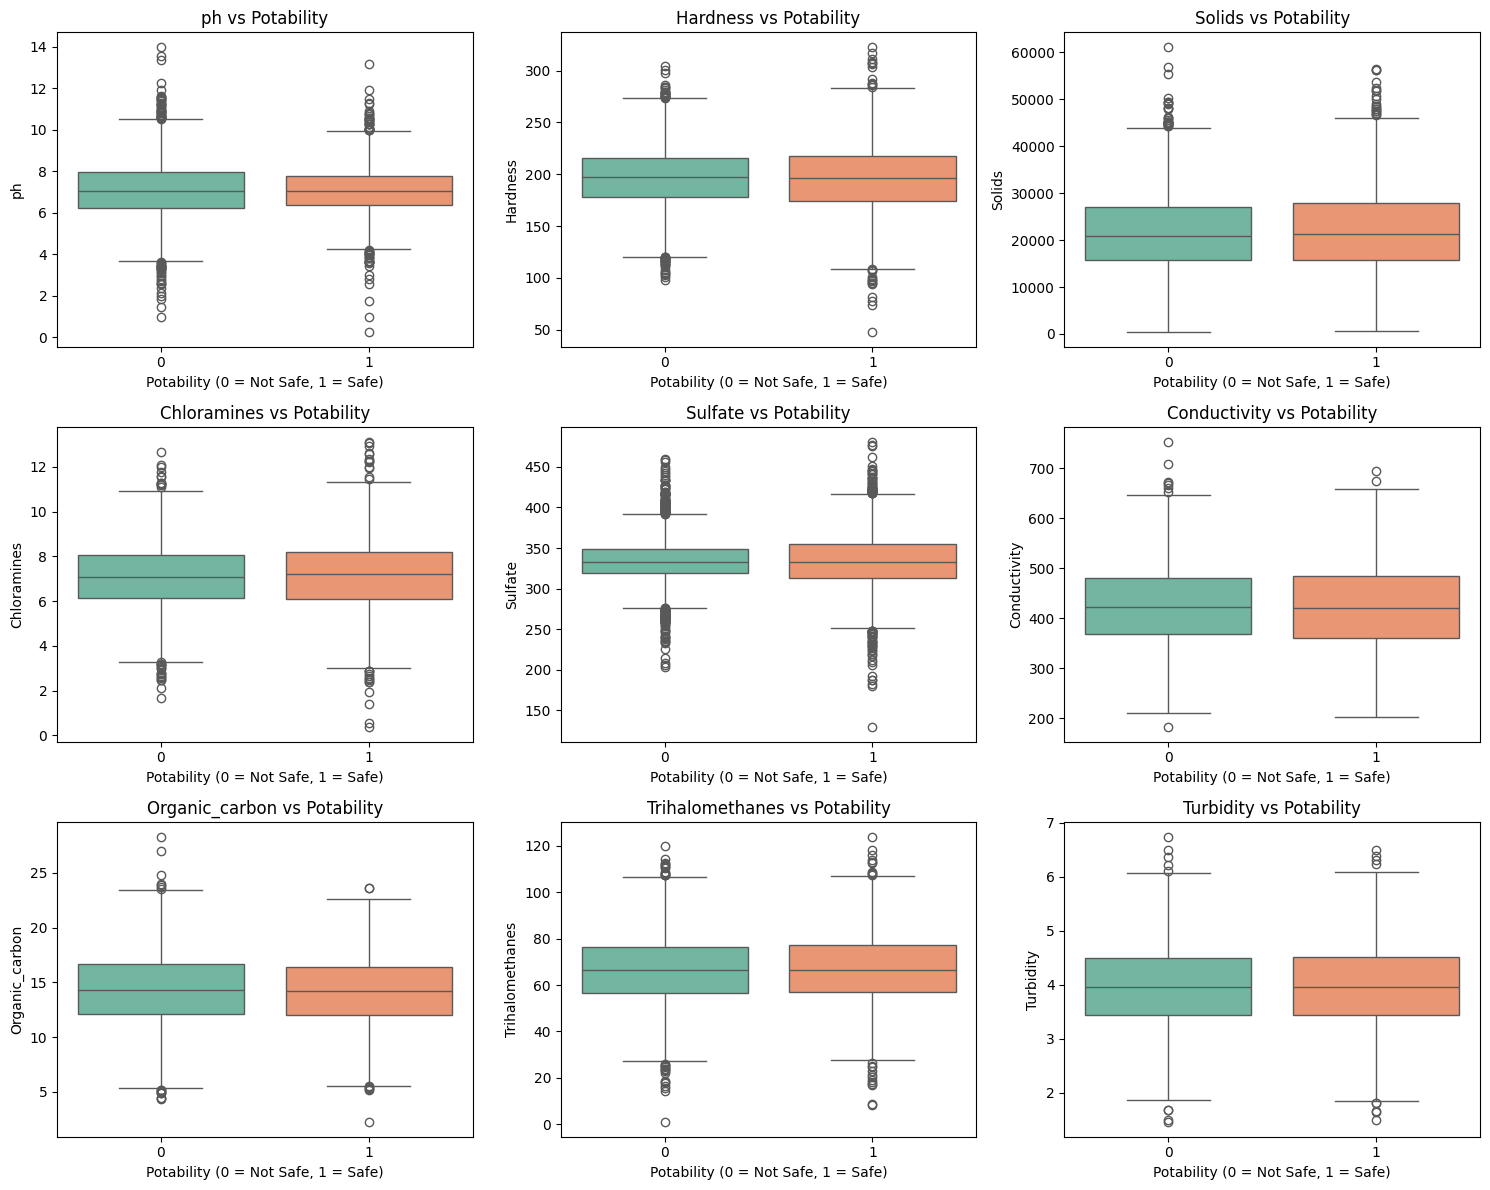

In [ ]:
# Create box plots for all features
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Potability', y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} vs Potability')
    axes[i].set_xlabel('Potability (0 = Not Safe, 1 = Safe)')

plt.tight_layout()
plt.show()

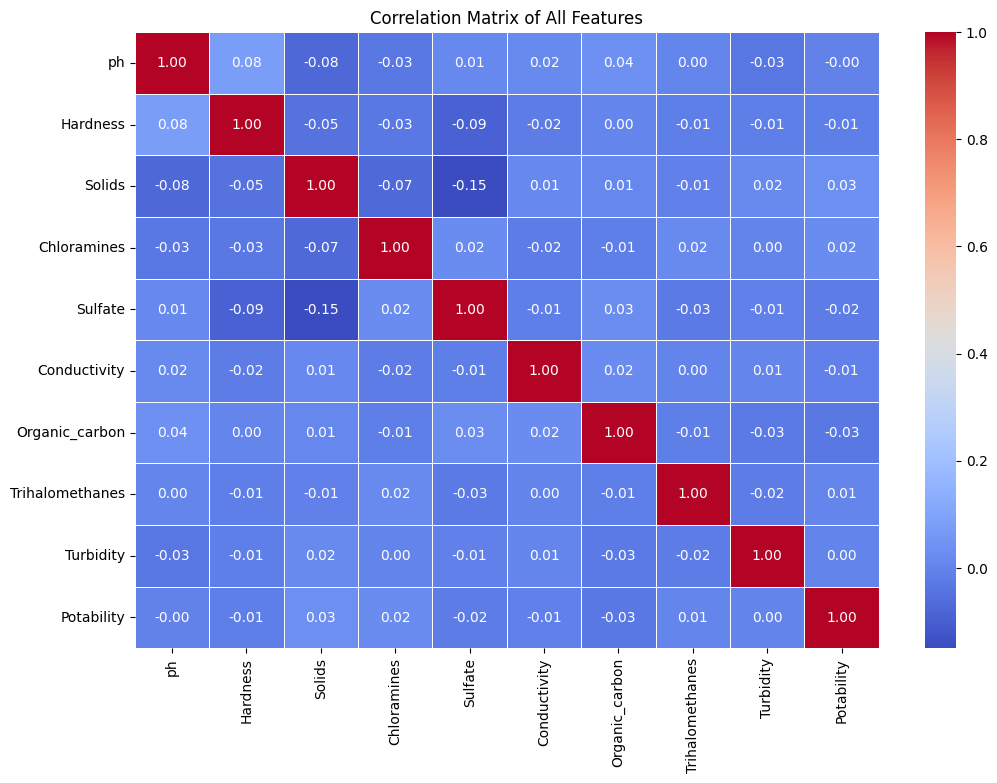

In [ ]:
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.show()

/tmp/ipykernel_711/4272792326.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability', data=df, palette='Set2')


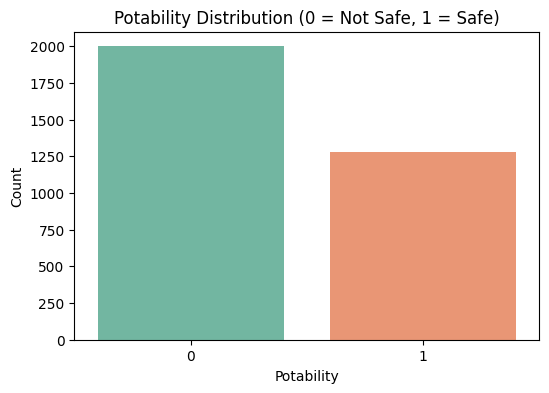

POTABILITY COUNT
Potability
0    1998
1    1278
Name: count, dtype: int64

 POTABILITY PERCENTAGE
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


In [ ]:
# Count plot for Potability
plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df, palette='Set2')
plt.title('Potability Distribution (0 = Not Safe, 1 = Safe)')
plt.xlabel('Potability')
plt.ylabel('Count')
plt.show()

# Print exact counts
print("POTABILITY COUNT")
print(df['Potability'].value_counts())
print("\n POTABILITY PERCENTAGE")
print(df['Potability'].value_counts(normalize=True) * 100)

##Feature Engineering and Scaling

In [ ]:
# Separate features (X) and target (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

print("FEATURES (X) SHAPE")
print(X.shape)

print("\n TARGET (y) SHAPE")
print(y.shape)

print("\n FEATURE NAMES")
print(X.columns.tolist())

FEATURES (X) SHAPE
(3276, 9)

 TARGET (y) SHAPE
(3276,)

 FEATURE NAMES
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


In [ ]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("TRAINING SET")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\n TESTING SET")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

# Check class balance in training set
print("\n TRAINING SET CLASS BALANCE")
print(y_train.value_counts(normalize=True) * 100)

TRAINING SET
X_train: (2620, 9)
y_train: (2620,)

 TESTING SET
X_test: (656, 9)
y_test: (656,)

 TRAINING SET CLASS BALANCE
Potability
0    60.992366
1    39.007634
Name: proportion, dtype: float64


In [ ]:
# Create scaler
scaler = StandardScaler()

# Fit on training data only (important!)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("BEFORE SCALING (first 3 rows)")
print(X_train.head(3))

print("\n AFTER SCALING (first 3 rows)")
print(X_train_scaled[:3])

BEFORE SCALING (first 3 rows)
            ph    Hardness        Solids  Chloramines     Sulfate  \
2214  7.822492  208.636720  22308.821729     5.850328  408.123255   
1634  6.037428  227.033994  12988.791229     8.476905  392.380529   
2605  8.445219  228.522860  28966.569327     6.179855  333.073546   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  
2214    502.789396       16.135732        60.393982   3.835332  
1634    306.386283        7.122391        41.190507   3.594217  
2605    361.705354       14.554220        60.612230   4.400706  

 AFTER SCALING (first 3 rows)
[[ 0.50505154  0.37129458  0.04803985 -0.79180869  2.05230791  0.92518305
   0.56524237 -0.36557553 -0.17745664]
 [-0.70967806  0.93508365 -1.01608039  0.85091664  1.61777683 -1.5016933
  -2.16944822 -1.58157951 -0.48650158]
 [ 0.92881527  0.98071034  0.80819229 -0.58571418 -0.01921589 -0.8181372
   0.08540402 -0.35175558  0.5472018 ]]


In [ ]:
# Convert scaled arrays back to DataFrames for easier reading
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("SCALED TRAINING DATA (first 5 rows)")
print(X_train_scaled.head())

SCALED TRAINING DATA (first 5 rows)
         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
0  0.505052  0.371295  0.048040    -0.791809  2.052308      0.925183   
1 -0.709678  0.935084 -1.016080     0.850917  1.617777     -1.501693   
2  0.928815  0.980710  0.808192    -0.585714 -0.019216     -0.818137   
3 -0.227969  0.671248 -0.001853     0.030738 -0.019216     -0.677955   
4 -0.390485  0.176673 -0.548156    -0.571875 -0.196177      0.665479   

   Organic_carbon  Trihalomethanes  Turbidity  
0        0.565242        -0.365576  -0.177457  
1       -2.169448        -1.581580  -0.486502  
2        0.085404        -0.351756   0.547202  
3        0.774861         0.501437  -0.091554  
4        0.686438        -1.264004  -0.544746  


##Logistic Regression

In [ ]:
# Create the model
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Train the model
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test_scaled)

# Check accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"LOGISTIC REGRESSION ACCURACY: {accuracy_lr:.4f}")

# Full report
print("\n CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_lr, target_names=['Not Safe', 'Safe']))

# Confusion matrix
print("\n CONFUSION MATRIX ")
print(confusion_matrix(y_test, y_pred_lr))

LOGISTIC REGRESSION ACCURACY: 0.5259

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Not Safe       0.64      0.52      0.57       400
        Safe       0.42      0.53      0.47       256

    accuracy                           0.53       656
   macro avg       0.53      0.53      0.52       656
weighted avg       0.55      0.53      0.53       656


 CONFUSION MATRIX 
[[209 191]
 [120 136]]


##Random Forest

In [ ]:
# Create the model
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test_scaled)

# Check accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"RANDOM FOREST ACCURACY: {accuracy_rf:.4f}")

# Full report
print("\n CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rf, target_names=['Not Safe', 'Safe']))

# Confusion matrix
print("\n CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred_rf))

RANDOM FOREST ACCURACY: 0.6646

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Not Safe       0.67      0.91      0.77       400
        Safe       0.66      0.29      0.40       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.58       656
weighted avg       0.66      0.66      0.62       656


 CONFUSION MATRIX
[[362  38]
 [182  74]]


##XGBoost

In [ ]:
# Create the model
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
xgb.fit(X_train_scaled, y_train)

# Make predictions
y_pred_xgb = xgb.predict(X_test_scaled)

# Check accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBOOST ACCURACY: {accuracy_xgb:.4f}")

# Full report
print("\n CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Safe', 'Safe']))

# Confusion matrix
print("\n CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred_xgb))

XGBOOST ACCURACY: 0.6555

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Not Safe       0.67      0.87      0.75       400
        Safe       0.61      0.32      0.42       256

    accuracy                           0.66       656
   macro avg       0.64      0.60      0.59       656
weighted avg       0.65      0.66      0.62       656


 CONFUSION MATRIX
[[348  52]
 [174  82]]


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [23:13:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


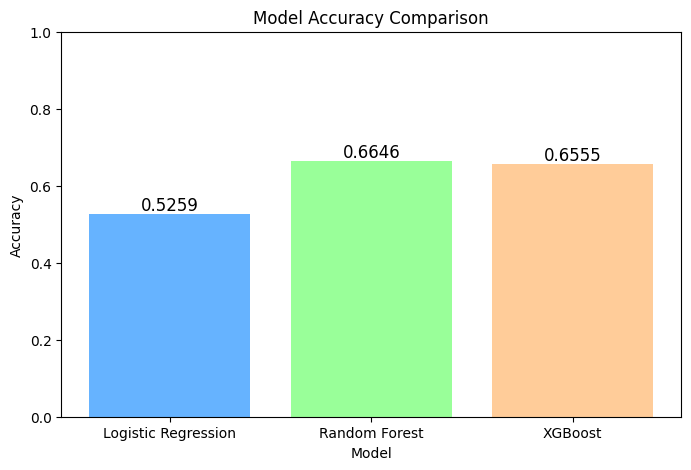

MODEL COMPARISON
Logistic Regression: 0.5259
Random Forest: 0.6646
XGBoost: 0.6555


In [ ]:
# Compare accuracies
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [accuracy_lr, accuracy_rf, accuracy_xgb]

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=12)

plt.show()

# Print summary
print("MODEL COMPARISON")
for name, acc in zip(models, accuracies):
    print(f"{name}: {acc:.4f}")

In [ ]:
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=['Not Safe', 'Safe']))

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Not Safe', 'Safe']))

print("\n" + "=" * 60)
print("XGBOOST")
print("=" * 60)
print(classification_report(y_test, y_pred_xgb, target_names=['Not Safe', 'Safe']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Not Safe       0.64      0.52      0.57       400
        Safe       0.42      0.53      0.47       256

    accuracy                           0.53       656
   macro avg       0.53      0.53      0.52       656
weighted avg       0.55      0.53      0.53       656


RANDOM FOREST
              precision    recall  f1-score   support

    Not Safe       0.67      0.91      0.77       400
        Safe       0.66      0.29      0.40       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.58       656
weighted avg       0.66      0.66      0.62       656


XGBOOST
              precision    recall  f1-score   support

    Not Safe       0.67      0.87      0.75       400
        Safe       0.61      0.32      0.42       256

    accuracy                           0.66       656
   macro avg       0.64      0.60      0.59       656
weighted avg       0.65      0

In [ ]:
# Test different numbers of trees
n_estimators_list = [50, 100, 200, 300, 500]
results = []

for n in n_estimators_list:
    rf_test = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_test.fit(X_train_scaled, y_train)
    y_pred = rf_test.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    results.append({'n_estimators': n, 'accuracy': acc, 'f1_safe': f1})
    print(f"n_estimators={n}: Accuracy={acc:.4f}, F1 (Safe)={f1:.4f}")

# Show best
best = max(results, key=lambda x: x['accuracy'])
print(f"\n BEST: n_estimators={best['n_estimators']} with accuracy={best['accuracy']:.4f}")

n_estimators=50: Accuracy=0.6616, F1 (Safe)=0.4064
n_estimators=100: Accuracy=0.6646, F1 (Safe)=0.4022
n_estimators=200: Accuracy=0.6723, F1 (Safe)=0.4142
n_estimators=300: Accuracy=0.6677, F1 (Safe)=0.3978
n_estimators=500: Accuracy=0.6723, F1 (Safe)=0.4044

 BEST: n_estimators=200 with accuracy=0.6723


In [ ]:
# Test different max depths
max_depth_list = [5, 10, 15, 20, None]
results_depth = []

for depth in max_depth_list:
    rf_test = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_test.fit(X_train_scaled, y_train)
    y_pred = rf_test.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    results_depth.append({'max_depth': depth, 'accuracy': acc, 'f1_safe': f1})
    print(f"max_depth={depth}: Accuracy={acc:.4f}, F1 (Safe)={f1:.4f}")

best_depth = max(results_depth, key=lambda x: x['accuracy'])
print(f"\n BEST: max_depth={best_depth['max_depth']} with accuracy={best_depth['accuracy']:.4f}")

max_depth=5: Accuracy=0.6448, F1 (Safe)=0.4902
max_depth=10: Accuracy=0.6707, F1 (Safe)=0.4680
max_depth=15: Accuracy=0.6662, F1 (Safe)=0.4282
max_depth=20: Accuracy=0.6570, F1 (Safe)=0.4000
max_depth=None: Accuracy=0.6723, F1 (Safe)=0.4142

 BEST: max_depth=None with accuracy=0.6723


In [ ]:
# Train the best model based on your tuning results
# Change the values below based on what you found
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_scaled, y_train)
y_pred_best = best_rf.predict(X_test_scaled)

print("TUNED RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=['Not Safe', 'Safe']))

TUNED RANDOM FOREST
Accuracy: 0.6662
              precision    recall  f1-score   support

    Not Safe       0.67      0.89      0.76       400
        Safe       0.65      0.32      0.43       256

    accuracy                           0.67       656
   macro avg       0.66      0.60      0.60       656
weighted avg       0.66      0.67      0.63       656



In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create the model
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # Optimize for F1, not accuracy
    n_jobs=-1,
    verbose=1
)

# This may take 2-3 minutes
grid_search.fit(X_train_scaled, y_train)

print("BEST PARAMETERS")
print(grid_search.best_params_)

print(f"\n BEST F1 SCORE (cross-validation): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
BEST PARAMETERS
{'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

 BEST F1 SCORE (cross-validation): 0.4945


TUNED RANDOM FOREST - TEST SET RESULTS

Accuracy: 0.6662
ROC-AUC: 0.6637

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Not Safe       0.69      0.83      0.75       400
        Safe       0.61      0.40      0.48       256

    accuracy                           0.67       656
   macro avg       0.65      0.62      0.62       656
weighted avg       0.66      0.67      0.65       656

CONFUSION MATRIX
[[334  66]
 [153 103]]


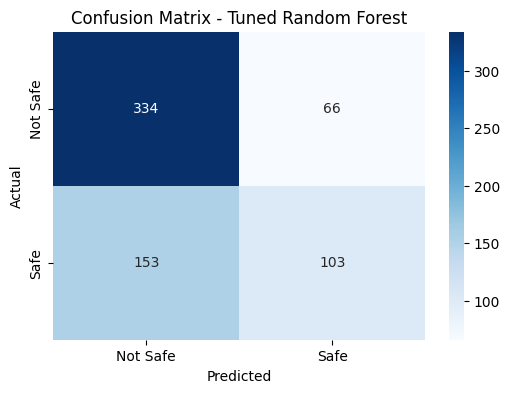

In [ ]:
# Get the best model from grid search
best_rf = grid_search.best_estimator_

# Make predictions on the test set
y_pred_best = best_rf.predict(X_test_scaled)

# Get probability predictions (for ROC curve)
y_prob_best = best_rf.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=" * 60)
print("TUNED RANDOM FOREST - TEST SET RESULTS")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_best, target_names=['Not Safe', 'Safe']))

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(confusion_matrix(y_test, y_pred_best))

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Safe', 'Safe'],
            yticklabels=['Not Safe', 'Safe'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Get probability predictions
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print("THRESHOLD TUNING")
print(f"{'Threshold':<12} {'Accuracy':<10} {'Precision(Safe)':<16} {'Recall(Safe)':<14} {'F1(Safe)':<10}")
print("-" * 70)

best_f1 = 0
best_threshold = 0.5

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)

    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1, zero_division=0)

    print(f"{thresh:<12} {acc:<10.4f} {prec:<16.4f} {rec:<14.4f} {f1:<10.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n BEST THRESHOLD: {best_threshold} with F1 (Safe) = {best_f1:.4f}")

THRESHOLD TUNING
Threshold    Accuracy   Precision(Safe)  Recall(Safe)   F1(Safe)  
----------------------------------------------------------------------
0.3          0.4588     0.4160           0.9570         0.5799    
0.35         0.5107     0.4381           0.8984         0.5890    
0.4          0.5473     0.4499           0.7188         0.5534    
0.45         0.6265     0.5201           0.5547         0.5369    
0.5          0.6662     0.6095           0.4023         0.4847    
0.55         0.6753     0.7129           0.2812         0.4034    
0.6          0.6662     0.7937           0.1953         0.3135    

 BEST THRESHOLD: 0.35 with F1 (Safe) = 0.5890


In [ ]:
# Get probability predictions
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print("THRESHOLD TUNING")
print(f"{'Threshold':<12} {'Accuracy':<10} {'Precision(Safe)':<16} {'Recall(Safe)':<14} {'F1(Safe)':<10}")
print("-" * 70)

best_f1 = 0
best_threshold = 0.5

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)

    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1, zero_division=0)

    print(f"{thresh:<12} {acc:<10.4f} {prec:<16.4f} {rec:<14.4f} {f1:<10.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n BEST THRESHOLD: {best_threshold} with F1 (Safe) = {best_f1:.4f}")

THRESHOLD TUNING
Threshold    Accuracy   Precision(Safe)  Recall(Safe)   F1(Safe)  
----------------------------------------------------------------------
0.3          0.4588     0.4160           0.9570         0.5799    
0.35         0.5107     0.4381           0.8984         0.5890    
0.4          0.5473     0.4499           0.7188         0.5534    
0.45         0.6265     0.5201           0.5547         0.5369    
0.5          0.6662     0.6095           0.4023         0.4847    
0.55         0.6753     0.7129           0.2812         0.4034    
0.6          0.6662     0.7937           0.1953         0.3135    

 BEST THRESHOLD: 0.35 with F1 (Safe) = 0.5890


/tmp/ipykernel_711/663281413.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


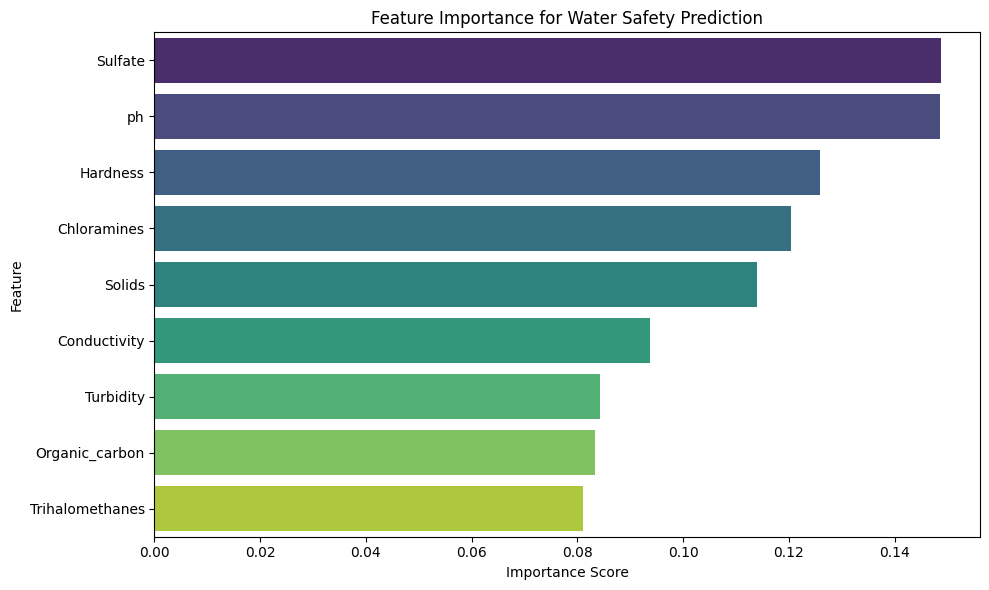

FEATURE IMPORTANCE
        Feature  Importance
        Sulfate    0.148713
             ph    0.148553
       Hardness    0.125903
    Chloramines    0.120476
         Solids    0.114022
   Conductivity    0.093717
      Turbidity    0.084365
 Organic_carbon    0.083264
Trihalomethanes    0.080988


In [ ]:
# Get feature importance
importances = best_rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for Water Safety Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("FEATURE IMPORTANCE")
print(importance_df.to_string(index=False))

In [ ]:
threshold = 0.50
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

print(f"\n FINAL MODEL (Threshold = {threshold})")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=['Not Safe', 'Safe']))
print("CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))


 FINAL MODEL (Threshold = 0.5)
Accuracy: 0.6662

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Not Safe       0.69      0.83      0.75       400
        Safe       0.61      0.40      0.48       256

    accuracy                           0.67       656
   macro avg       0.65      0.62      0.62       656
weighted avg       0.66      0.67      0.65       656

CONFUSION MATRIX
[[334  66]
 [153 103]]


In [ ]:

import joblib
# STEP 7: Save model, scaler, and threshold
joblib.dump(best_rf, 'water_quality_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

with open('threshold.txt', 'w') as f:
    f.write(str(threshold))

print("\n Files saved:")
print("   - water_quality_model.pkl")
print("   - scaler.pkl")
print("   - threshold.txt")


 Files saved:
   - water_quality_model.pkl
   - scaler.pkl
   - threshold.txt


In [ ]:
# Download all three files
files.download('water_quality_model.pkl')
files.download('scaler.pkl')
files.download('threshold.txt')

print("\n Download started. Check your browser downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Download started. Check your browser downloads folder.


In [ ]:

# CREATE REQUIREMENTS.TXT

requirements = """streamlit
pandas
numpy
scikit-learn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Saved: requirements.txt")

Saved: requirements.txt


In [ ]:
print("\nDownloading files...")
files.download('water_quality_model.pkl')
files.download('scaler.pkl')
files.download('threshold.txt')
files.download('requirements.txt')

print("\n All files downloaded. Check your browser downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 All files downloaded. Check your browser downloads folder.


## Insights

The data had real problems: `ph` was missing 15%, `Sulfate` 24%, `Trihalomethanes` 5%, and one row had `pH = 0`, which is impossible for drinking water. I treated that zero as missing and filled everything with the median. No duplicates, so the cleaned set stayed at 3,276 rows.

The EDA findings tells more about the dataset. Safe and unsafe water have almost identical averages, box plots overlap heavily, and no feature correlates with `Potability` above 0.03. Features aren't strongly correlated with each other either (max -0.15), so no multicollinearity but also no easy signal. Linear models were never going to work here, and Logistic Regression confirmed it at 52.6%. Random Forest hit 66.5%, XGBoost 65.6%, and my tuned Random Forest landed at **66.6% accuracy, ROC-AUC 0.664, F1 (Safe) 0.48** at threshold 0.50.

Threshold tuning forced a real decision. The code picked 0.35 as best F1 for Safe (0.589), but accuracy fell to 51.1% and false positives spiked. A false positive means telling someone contaminated water is safe. So I kept **threshold 0.50**, accepting a lower F1 to cut false positives from 131 to 66. Top features were `Sulfate`, `ph`, `Hardness`, `Chloramines`, and `Solids`.


## Conclusion

Water potability is hard to predict from these nine features. No single feature separates safe from unsafe, the patterns are nonlinear, and the best model tops out around 67%. My tuned Random Forest with threshold 0.50 gives the safest balance: **66.6% accuracy, ROC-AUC 0.664, F1 (Safe) 0.48**. It leans toward caution — missing safe water (153 false negatives) rather than falsely calling contaminated water safe (66 false positives). That's the right trade-off for this problem. The model is a useful decision-support tool, not a certified test, and there's clear room to improve with better features and validation.